# 04 Transformer Model - BioBERT

This notebook fine-tunes **BioBERT** on the combined **FakeHealth + healthfact** binary misinformation dataset.


**BioBERT** because it is a stronger domain-specific model for biomedical and health language than general model like DistilBERT.our task is health misinformation detection, this gives us a more meaningful transformer benchmark for medical claims, health news, and public health text.


current environment is **CPU-only**, so BioBERT training will be slower than GPU training. To keep the first run realistic in Jupyter Notebook, this notebook starts with conservative settings:

- `num_train_epochs = 1`to 5
- `per_device_train_batch_size = 4`
- `gradient_accumulation_steps = 2`
- `max_length = 256`

Once the first run completes successfully, you can increase the epochs to `2` or `3` for a stronger result.


## Model Download
- `dmis-lab/biobert-base-cased-v1.1`


In [19]:
from pathlib import Path
import json
import os
import random

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)


In [20]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
DATA_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'fakehealth_healthfact_binary_clean.csv'
MODEL_DIR = PROJECT_ROOT / 'model' / 'biobert_fakehealth_healthfact'
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'biobert_fakehealth_healthfact'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.1'
MAX_LENGTH = 256
NUM_EPOCHS = 5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
LEARNING_RATE = 2e-5
RANDOM_STATE = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Model:', MODEL_NAME)


Device: cpu
Model: dmis-lab/biobert-base-cased-v1.1


In [21]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)


In [22]:
df = pd.read_csv(DATA_PATH)
TEXT_COL = "model_text" if "model_text" in df.columns else "text"
preview_cols = list(dict.fromkeys(["dataset", "split", "record_id", "label", "text", TEXT_COL]))

print("Shape:", df.shape)
print("Dataset counts:", df["dataset"].value_counts().to_dict())
print("Label counts:", df["label"].value_counts().to_dict())
print("Text column:", TEXT_COL)
df[preview_cols].head(3)


Shape: (12273, 16)
Dataset counts: {'healthfact': 10075, 'fakehealth': 2156, 'curated_health_claims': 42}
Label counts: {1: 7563, 0: 4710}
Text column: model_text


,dataset,split,record_id,label,text,model_text
0,fakehealth,release,news_reviews_00000,0,"MADISON, Wis. -- More than 700 million adults ...",Tiny implantable device short-circuits hunger ...
1,fakehealth,release,news_reviews_00001,1,"Wilmington, DE, December 17, 2018 - The CRISPR...",Scientists report CRISPR restores effectivenes...
2,fakehealth,release,news_reviews_00002,0,About 3 million people in the US are diagnosed...,Probiotics could help millions of patients suf...


## Split Strategy

We use the same split logic as the baseline notebook so the BioBERT results are comparable:

- keep original `healthfact` `train/dev/test`
- create a stratified split for `FakeHealth`
- merge the corresponding partitions


In [23]:
VALID_SPLITS = {"train", "dev", "test"}
CURATED_TRAIN_REPEAT = 4


def make_train_dev_test(data: pd.DataFrame, random_state: int = 42):
    # Respect existing train/dev/test splits and split unsplit datasets reproducibly.
    data = data.copy()
    data["split"] = data["split"].fillna("").astype(str).str.lower().str.strip()

    fixed = data[data["split"].isin(VALID_SPLITS)].copy()
    unsplit = data[~data["split"].isin(VALID_SPLITS)].copy()

    split_frames = {
        "train": [fixed[fixed["split"] == "train"]],
        "dev": [fixed[fixed["split"] == "dev"]],
        "test": [fixed[fixed["split"] == "test"]],
    }

    for dataset_name, group in unsplit.groupby("dataset"):
        group = group.copy()
        if len(group) < 10 or group["label"].nunique() < 2:
            group["split"] = "train"
            split_frames["train"].append(group)
            continue

        train_part, temp_part = train_test_split(
            group,
            test_size=0.30,
            stratify=group["label"],
            random_state=random_state,
        )
        dev_part, test_part = train_test_split(
            temp_part,
            test_size=0.50,
            stratify=temp_part["label"],
            random_state=random_state,
        )
        train_part = train_part.copy()
        dev_part = dev_part.copy()
        test_part = test_part.copy()
        train_part["split"] = "train"
        dev_part["split"] = "dev"
        test_part["split"] = "test"
        split_frames["train"].append(train_part)
        split_frames["dev"].append(dev_part)
        split_frames["test"].append(test_part)

    train_df = pd.concat(split_frames["train"], ignore_index=True)
    dev_df = pd.concat(split_frames["dev"], ignore_index=True)
    test_df = pd.concat(split_frames["test"], ignore_index=True)

    curated_train = train_df[train_df["dataset"] == "curated_health_claims"]
    if not curated_train.empty and CURATED_TRAIN_REPEAT > 1:
        train_df = pd.concat(
            [train_df] + [curated_train.copy() for _ in range(CURATED_TRAIN_REPEAT - 1)],
            ignore_index=True,
        )

    return train_df.sample(frac=1, random_state=random_state).reset_index(drop=True), dev_df, test_df


train_df, dev_df, test_df = make_train_dev_test(df, random_state=RANDOM_STATE if "RANDOM_STATE" in globals() else 42)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)
print("Text column:", TEXT_COL)
print("Train labels:", train_df["label"].value_counts().to_dict())
print("Dev labels:", dev_df["label"].value_counts().to_dict())
print("Test labels:", test_df["label"].value_counts().to_dict())
print("Train datasets:", train_df["dataset"].value_counts().to_dict())


Train shape: (9708, 16)
Dev shape: (1338, 16)
Test shape: (1317, 16)
Text column: model_text
Train labels: {1: 6003, 0: 3705}
Dev labels: {1: 817, 0: 521}
Test labels: {1: 788, 0: 529}
Train datasets: {'healthfact': 8079, 'fakehealth': 1509, 'curated_health_claims': 120}


In [24]:
train_df.to_csv(OUTPUT_DIR / 'train_split.csv', index=False)
dev_df.to_csv(OUTPUT_DIR / 'dev_split.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test_split.csv', index=False)
print('Saved train/dev/test split files to', OUTPUT_DIR)


Saved train/dev/test split files to C:\Users\ribam\Desktop\Reseach\Dataset\output\biobert_fakehealth_healthfact


In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'misinformation', 1: 'reliable'},
    label2id={'misinformation': 0, 'reliable': 1},
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
class HealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
        )
        encoded['labels'] = int(self.labels[idx])
        return encoded


In [27]:
train_dataset = HealthDataset(train_df[TEXT_COL], train_df["label"], tokenizer, MAX_LENGTH)
dev_dataset = HealthDataset(dev_df[TEXT_COL], dev_df["label"], tokenizer, MAX_LENGTH)
test_dataset = HealthDataset(test_df[TEXT_COL], test_df["label"], tokenizer, MAX_LENGTH)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

len(train_dataset), len(dev_dataset), len(test_dataset)


(9708, 1338, 1317)

In [28]:
def metrics_from_predictions(y_true, y_pred, prefix="eval"):
    reliable_precision, reliable_recall, reliable_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    misinfo_precision, misinfo_recall, misinfo_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=0, zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        f"{prefix}_accuracy": float(accuracy_score(y_true, y_pred)),
        f"{prefix}_precision": float(reliable_precision),
        f"{prefix}_recall": float(reliable_recall),
        f"{prefix}_f1": float(reliable_f1),
        f"{prefix}_macro_precision": float(macro_precision),
        f"{prefix}_macro_recall": float(macro_recall),
        f"{prefix}_macro_f1": float(macro_f1),
        f"{prefix}_misinformation_precision": float(misinfo_precision),
        f"{prefix}_misinformation_recall": float(misinfo_recall),
        f"{prefix}_misinformation_f1": float(misinfo_f1),
        f"{prefix}_reliable_precision": float(reliable_precision),
        f"{prefix}_reliable_recall": float(reliable_recall),
        f"{prefix}_reliable_f1": float(reliable_f1),
    }


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    metrics = metrics_from_predictions(labels, predictions, prefix="")
    return {key.lstrip("_"): value for key, value in metrics.items()}


In [29]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    do_train=True,
    do_eval=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=3,
    report_to='none',
    seed=RANDOM_STATE,
    use_cpu=not torch.cuda.is_available(),
    remove_unused_columns=True,
    group_by_length=True,
)


In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


C:\Users\ribam\AppData\Local\Temp\ipykernel_49324\3353815994.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [31]:
train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro Precision,Macro Recall,Macro F1,Misinformation Precision,Misinformation Recall,Misinformation F1,Reliable Precision,Reliable Recall,Reliable F1
1,0.497700,0.511426,0.733184,0.768065,0.806610,0.786866,0.719449,0.712326,0.715111,0.670833,0.618042,0.643357,0.768065,0.806610,0.786866
2,0.412000,0.486262,0.763827,0.792982,0.829865,0.811005,0.752599,0.745067,0.748132,0.712215,0.660269,0.685259,0.792982,0.829865,0.811005
3,0.311200,0.665958,0.758595,0.772026,0.858017,0.812754,0.751129,0.730352,0.736556,0.730233,0.602687,0.660358,0.772026,0.858017,0.812754
4,0.160000,0.886398,0.753363,0.790920,0.810282,0.800484,0.740769,0.737195,0.738794,0.690619,0.664107,0.677104,0.790920,0.810282,0.800484
5,0.172600,1.296505,0.753363,0.801735,0.791922,0.796798,0.740792,0.742410,0.741555,0.679849,0.692898,0.686312,0.801735,0.791922,0.796798


TrainOutput(global_step=6070, training_loss=0.3241503935472969, metrics={'train_runtime': 11368.6982, 'train_samples_per_second': 4.27, 'train_steps_per_second': 0.534, 'total_flos': 1451665914625920.0, 'train_loss': 0.3241503935472969, 'epoch': 5.0})

In [49]:
from pathlib import Path
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import AutoModelForSequenceClassification

checkpoint_root = OUTPUT_DIR / "checkpoints"
checkpoint_dirs = sorted(checkpoint_root.glob("checkpoint-*"))

print("Found checkpoints:")
for p in checkpoint_dirs:
    print(" -", p.name)

if not checkpoint_dirs:
    raise FileNotFoundError(f"No checkpoints found in {checkpoint_root}")

def predict_with_checkpoint(checkpoint_dir, frame, batch_size=16, return_probs=False):
    model = AutoModelForSequenceClassification.from_pretrained(str(checkpoint_dir))
    model.to(DEVICE)
    model.eval()

    texts = frame[TEXT_COL].astype(str).tolist()
    preds = []
    probs_all = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds.extend(np.argmax(probs, axis=-1).tolist())
        probs_all.append(probs)

    preds = np.array(preds)

    if return_probs:
        return preds, np.vstack(probs_all)

    return preds

results = []

for checkpoint_dir in checkpoint_dirs:
    dev_pred = predict_with_checkpoint(checkpoint_dir, dev_df)
    dev_y = dev_df["label"].to_numpy()

    _, _, dev_macro_f1, _ = precision_recall_fscore_support(
        dev_y,
        dev_pred,
        average="macro",
        zero_division=0,
    )

    dev_acc = accuracy_score(dev_y, dev_pred)

    results.append({
        "checkpoint": checkpoint_dir,
        "dev_accuracy": dev_acc,
        "dev_macro_f1": dev_macro_f1,
    })

results = sorted(results, key=lambda x: x["dev_macro_f1"], reverse=True)

print("\nCheckpoint ranking:")
for row in results:
    print(
        row["checkpoint"].name,
        "acc=", round(row["dev_accuracy"], 4),
        "macro_f1=", round(row["dev_macro_f1"], 4),
    )

BEST_MODEL_CHECKPOINT = results[0]["checkpoint"]
print("\nUsing best checkpoint:", BEST_MODEL_CHECKPOINT)

eval_model = AutoModelForSequenceClassification.from_pretrained(str(BEST_MODEL_CHECKPOINT))
eval_model.to(DEVICE)
eval_model.eval()

dev_pred_labels, dev_probabilities = predict_with_checkpoint(
    BEST_MODEL_CHECKPOINT,
    dev_df,
    return_probs=True,
)

test_pred_labels, test_probabilities = predict_with_checkpoint(
    BEST_MODEL_CHECKPOINT,
    test_df,
    return_probs=True,
)

dev_metrics = metrics_from_predictions(dev_df["label"].to_numpy(), dev_pred_labels, prefix="eval")
test_metrics = metrics_from_predictions(test_df["label"].to_numpy(), test_pred_labels, prefix="eval")

print("\nTest report for best checkpoint:")
print(classification_report(
    test_df["label"],
    test_pred_labels,
    labels=[0, 1],
    target_names=["misinformation", "reliable"],
    digits=4,
))

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Found checkpoints:
 - checkpoint-2428
 - checkpoint-4856
 - checkpoint-6070

Checkpoint ranking:
checkpoint-2428 acc= 0.7638 macro_f1= 0.7481
checkpoint-6070 acc= 0.7534 macro_f1= 0.7416
checkpoint-4856 acc= 0.7534 macro_f1= 0.7388

Using best checkpoint: C:\Users\ribam\Desktop\Reseach\Dataset\output\biobert_fakehealth_healthfact\checkpoints\checkpoint-2428

Test report for best checkpoint:
                precision    recall  f1-score   support

misinformation     0.6985    0.6919    0.6952       529
      reliable     0.7945    0.7995    0.7970       788

      accuracy                         0.7563      1317
     macro avg     0.7465    0.7457    0.7461      1317
  weighted avg     0.7559    0.7563    0.7561      1317


Test metrics:
  eval_accuracy: 0.7562642369020501
  eval_precision: 0.7944514501891551
  eval_recall: 0.799492385786802
  eval_f1: 0.7969639468690702
  eval_macro_precision: 0.7464623663159515
  eval_macro_recall: 0.7456819206816807
  eval_macro_f1: 0.74606032101288

In [50]:
print(classification_report(
    test_df["label"],
    test_pred_labels,
    labels=[0, 1],
    target_names=["misinformation", "reliable"],
    digits=4,
))


                precision    recall  f1-score   support

misinformation     0.6985    0.6919    0.6952       529
      reliable     0.7945    0.7995    0.7970       788

      accuracy                         0.7563      1317
     macro avg     0.7465    0.7457    0.7461      1317
  weighted avg     0.7559    0.7563    0.7561      1317



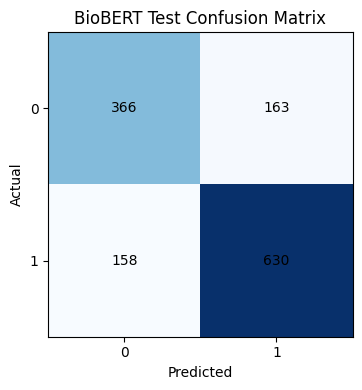

In [51]:
os.environ['MPLCONFIGDIR'] = str(OUTPUT_DIR / '.matplotlib')
(OUTPUT_DIR / '.matplotlib').mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['label'], test_pred_labels)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('BioBERT Test Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


In [52]:
eval_model.save_pretrained(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))

metrics = {
    "model_name": MODEL_NAME,
    "text_column": TEXT_COL,
    "max_length": MAX_LENGTH,
    "num_epochs": NUM_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "device": str(DEVICE),
    "train_rows": int(len(train_df)),
    "dev_rows": int(len(dev_df)),
    "test_rows": int(len(test_df)),
    "curated_train_repeat": CURATED_TRAIN_REPEAT,
    "best_model_checkpoint": str(BEST_MODEL_CHECKPOINT) if BEST_MODEL_CHECKPOINT is not None else None,
    "metrics_source": "explicit_best_checkpoint_predictions",
    "dev_metrics": {k: float(v) for k, v in dev_metrics.items() if isinstance(v, (int, float))},
    "test_metrics": {k: float(v) for k, v in test_metrics.items() if isinstance(v, (int, float))},
}

(OUTPUT_DIR / "biobert_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

output_cols = [c for c in ["dataset", "split", "record_id", "label", "text", "model_text"] if c in test_df.columns]
prediction_df = test_df[output_cols].copy()
prediction_df["prediction"] = test_pred_labels
prediction_df["prob_class_0"] = test_probabilities[:, 0]
prediction_df["prob_class_1"] = test_probabilities[:, 1]
prediction_df.to_csv(OUTPUT_DIR / "biobert_test_predictions.csv", index=False)

print("Saved best checkpoint model to:", MODEL_DIR)
print("Saved outputs to:", OUTPUT_DIR)
metrics


Saved best checkpoint model to: C:\Users\ribam\Desktop\Reseach\Dataset\model\biobert_fakehealth_healthfact
Saved outputs to: C:\Users\ribam\Desktop\Reseach\Dataset\output\biobert_fakehealth_healthfact


{'model_name': 'dmis-lab/biobert-base-cased-v1.1',
 'text_column': 'model_text',
 'max_length': 256,
 'num_epochs': 5,
 'train_batch_size': 4,
 'eval_batch_size': 4,
 'gradient_accumulation_steps': 2,
 'learning_rate': 2e-05,
 'device': 'cpu',
 'train_rows': 9708,
 'dev_rows': 1338,
 'test_rows': 1317,
 'curated_train_repeat': 4,
 'best_model_checkpoint': 'C:\\Users\\ribam\\Desktop\\Reseach\\Dataset\\output\\biobert_fakehealth_healthfact\\checkpoints\\checkpoint-2428',
 'metrics_source': 'explicit_best_checkpoint_predictions',
 'dev_metrics': {'eval_accuracy': 0.7638266068759342,
  'eval_precision': 0.7929824561403509,
  'eval_recall': 0.8298653610771114,
  'eval_f1': 0.8110047846889952,
  'eval_macro_precision': 0.752598888525662,
  'eval_macro_recall': 0.7450670375443138,
  'eval_macro_f1': 0.7481318744162107,
  'eval_misinformation_precision': 0.7122153209109731,
  'eval_misinformation_recall': 0.6602687140115163,
  'eval_misinformation_f1': 0.6852589641434262,
  'eval_reliable_prec

 this is BioBERT baseline, the best next comparison would be **PubMedBERT** using the exact same split strategy and evaluation pipeline.
